<h1>Setup for Sentiment Analysis</h1>
<h2>Setup and Import Dataset:</h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Our dataset with sentiment labels
data = {
    'complaint_text': [
        # Critical complaints (urgent)
        "Electric wire sparking near children playground very dangerous",
        "Building collapse risk people lives in danger immediately help",
        "No water in government hospital patients suffering critically",
        "Electric pole fell on road someone will die please urgent",
        "Child fell in open manhole on dark street emergency",
        "Gas leak smell coming from underground pipe dangerous",
        "Flood water entering houses people trapped need help now",
        "Dead body smell from abandoned building health emergency",
        "High voltage wire touching water dangerous for residents",
        "Bridge cracks getting bigger will collapse anytime urgent",
        "Sewage water mixing with drinking water disease spreading",
        "Fire hazard electric short circuit in market area urgent",

        # Negative complaints (frustrated but not emergency)
        "Water not coming in our area since 3 days",
        "Roads full of potholes damaging our vehicles daily",
        "Garbage not collected for a week very bad smell",
        "Streetlight broken near our street for many days",
        "No electricity since last night very inconvenient",
        "Sewage water overflowing onto street very dirty",
        "Public toilet broken and unusable for residents",
        "Traffic signal not working causing traffic problems",
        "Road construction incomplete blocking our path",
        "Water is dirty and smells bad in our taps",
        "Garbage dumped illegally near our colony boundary",
        "Bus service stopped in our area no transport",

        # Neutral complaints (requests/suggestions)
        "Please consider installing speed breaker near school",
        "Requesting street light installation in our lane",
        "Kindly arrange water supply timing information",
        "Please clean the public park near our society",
        "Request for dustbin installation near bus stop",
        "Suggest adding more buses on route number 5",
        "Please repair footpath near market area",
        "Requesting information about garbage collection schedule",
        "Could you please look into the water supply issue",
        "Gentle reminder about road repair request submitted",
        "Please consider our request for street lighting",
        "Kindly inform us about drainage repair schedule",

        # Positive feedback
        "Thank you for fixing the water supply so quickly",
        "Great work by sanitation team our area is clean",
        "Roads repaired nicely thank you municipality",
        "Electricity restored quickly appreciate the fast service",
        "New streetlights installed very happy with the work",
        "Garbage collected on time today very satisfied",
    ],
    'sentiment': (
        ['Critical'] * 12 +
        ['Negative'] * 12 +
        ['Neutral'] * 12 +
        ['Positive'] * 6
    )
}

df = pd.DataFrame(data)
print("Dataset created!")
print(f"Total complaints: {len(df)}")
print("\nSentiment distribution:")
print(df['sentiment'].value_counts())

Dataset created!
Total complaints: 42

Sentiment distribution:
sentiment
Critical    12
Negative    12
Neutral     12
Positive     6
Name: count, dtype: int64


<h1>Sentiment EDA</h1>
<h2>Visualize Sentiment Distribution:</h2>

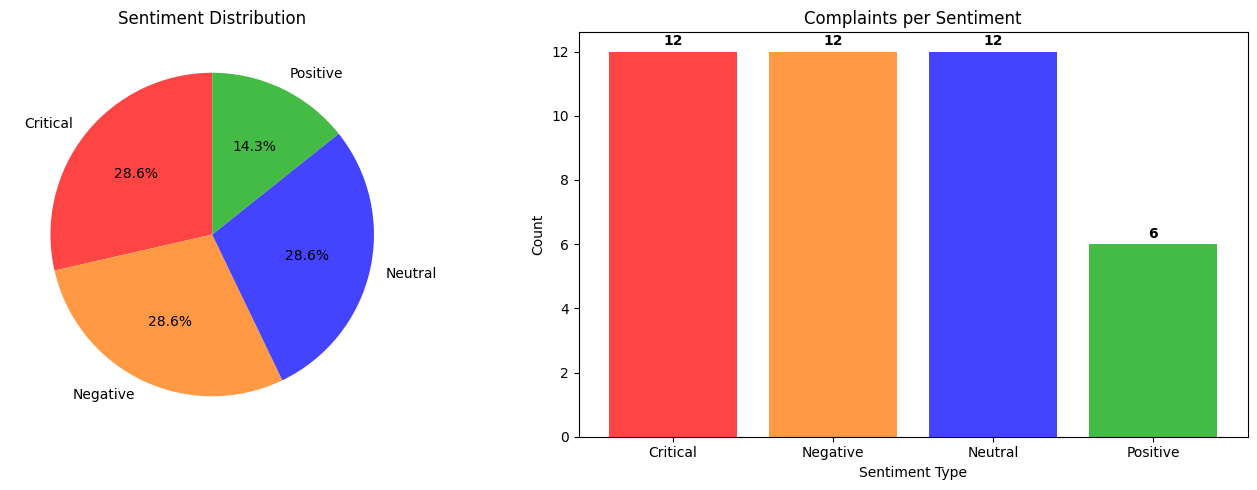

Sentiment charts saved!

=== SAMPLE COMPLAINTS PER SENTIMENT ===

Critical:
  'Electric wire sparking near children playground very dangerous'

Negative:
  'Water not coming in our area since 3 days'

Neutral:
  'Please consider installing speed breaker near school'

Positive:
  'Thank you for fixing the water supply so quickly'



In [2]:
# 1. Sentiment distribution pie chart
plt.figure(figsize=(14, 5))

# Pie chart
plt.subplot(1, 2, 1)
colors = ['#ff4444', '#ff9944', '#4444ff', '#44bb44']
df['sentiment'].value_counts().plot(
    kind='pie',
    colors=colors,
    autopct='%1.1f%%',  # Show percentage
    startangle=90
)
plt.title('Sentiment Distribution')
plt.ylabel('')

# Bar chart
plt.subplot(1, 2, 2)
sentiment_order = ['Critical', 'Negative', 'Neutral', 'Positive']
counts = [df[df['sentiment']==s].shape[0] for s in sentiment_order]
bars = plt.bar(sentiment_order, counts, 
               color=['#ff4444','#ff9944','#4444ff','#44bb44'])

# Add numbers on top of bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.2,
             str(count), 
             ha='center', 
             fontweight='bold')

plt.title('Complaints per Sentiment')
plt.xlabel('Sentiment Type')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('sentiment_distribution.png')
plt.show()
print("Sentiment charts saved!")

# 2. Sample complaints per sentiment
print("\n=== SAMPLE COMPLAINTS PER SENTIMENT ===\n")
for sentiment in sentiment_order:
    sample = df[df['sentiment']==sentiment]['complaint_text'].iloc[0]
    print(f"{sentiment}:")
    print(f"  '{sample}'")
    print()

<h1>Text Cleaning for Sentiment</h1>
<h2>Text Cleaning for Sentiment:</h2>

In [3]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# IMPORTANT: For sentiment we keep some words
# that we removed before!
# "not", "very", "urgent" carry sentiment meaning!
sentiment_stopwords = stop_words - {
    'not', 'very', 'no', 'never', 
    'urgent', 'dangerous', 'please',
    'thank', 'immediately'
}

def clean_sentiment_text(text):
    # Lowercase
    text = text.lower()
    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Split into words
    words = text.split()
    # Remove stopwords but KEEP sentiment words
    words = [lemmatizer.lemmatize(w) for w in words
             if w not in sentiment_stopwords]
    return ' '.join(words)

# Apply cleaning
df['cleaned_text'] = df['complaint_text'].apply(
    clean_sentiment_text
)

# Compare before and after
print("=== CLEANING COMPARISON ===\n")
for i in [0, 12, 24, 36]:
    print(f"Sentiment: {df['sentiment'][i]}")
    print(f"Before: {df['complaint_text'][i]}")
    print(f"After:  {df['cleaned_text'][i]}")
    print()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\alok_\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\alok_\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\alok_\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


=== CLEANING COMPARISON ===

Sentiment: Critical
Before: Electric wire sparking near children playground very dangerous
After:  electric wire sparking near child playground very dangerous

Sentiment: Negative
Before: Water not coming in our area since 3 days
After:  water not coming area since day

Sentiment: Neutral
Before: Please consider installing speed breaker near school
After:  please consider installing speed breaker near school

Sentiment: Positive
Before: Thank you for fixing the water supply so quickly
After:  thank fixing water supply quickly



<h1>TF-IDF + Label Encoding</h1>
<h2>TF-IDF + Label Encoding:</h2>

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# TF-IDF for sentiment (keep more features)
sentiment_vectorizer = TfidfVectorizer(
    max_features=100,  # More features than Day 2
    ngram_range=(1,2)  # Learn single words AND pairs!
)

# Convert text to numbers
X = sentiment_vectorizer.fit_transform(df['cleaned_text'])

# Convert sentiment labels to numbers
# Machine needs numbers not words!
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['sentiment'])

print("=== TF-IDF + ENCODING DONE ===\n")
print(f"TF-IDF Matrix shape: {X.shape}")
print(f"complaints x features = {X.shape[0]} x {X.shape[1]}")

print("\nSentiment labels as numbers:")
for text, number in zip(
    label_encoder.classes_,
    range(len(label_encoder.classes_))
):
    print(f"  {text} → {number}")

print("\nFirst 5 encoded labels:")
print(y[:5])
print("These are:", label_encoder.inverse_transform(y[:5]))

=== TF-IDF + ENCODING DONE ===

TF-IDF Matrix shape: (42, 100)
complaints x features = 42 x 100

Sentiment labels as numbers:
  Critical → 0
  Negative → 1
  Neutral → 2
  Positive → 3

First 5 encoded labels:
[0 0 0 0 0]
These are: ['Critical' 'Critical' 'Critical' 'Critical' 'Critical']


<h1>Train Sentiment Classifier</h1>
<h2>Train Sentiment Models:</h2>

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
import numpy as np

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Keep same ratio of sentiments!
)

print("=== DATA SPLIT ===")
print(f"Training: {X_train.shape[0]} complaints")
print(f"Testing:  {X_test.shape[0]} complaints")

print("\n=== TRAINING 3 MODELS ===\n")

# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_score = cross_val_score(lr, X, y, cv=5).mean()
print(f"Logistic Regression accuracy: {lr_score*100:.2f}%")

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_score = cross_val_score(rf, X, y, cv=5).mean()
print(f"Random Forest accuracy:       {rf_score*100:.2f}%")

# Model 3: SVM (NEW algorithm!)
svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)
svm_score = cross_val_score(svm, X, y, cv=5).mean()
print(f"SVM accuracy:                 {svm_score*100:.2f}%")

print("\n=== MODEL COMPARISON ===")
models = {
    'Logistic Regression': lr_score,
    'Random Forest': rf_score,
    'SVM': svm_score
}
winner = max(models, key=models.get)
for model, score in models.items():
    bar = "█" * int(score * 20)
    print(f"{model:22} {score*100:.2f}% {bar}")

print(f"\n🏆 Winner: {winner}!")

=== DATA SPLIT ===
Training: 33 complaints
Testing:  9 complaints

=== TRAINING 3 MODELS ===

Logistic Regression accuracy: 61.11%
Random Forest accuracy:       56.94%
SVM accuracy:                 66.11%

=== MODEL COMPARISON ===
Logistic Regression    61.11% ████████████
Random Forest          56.94% ███████████
SVM                    66.11% █████████████

🏆 Winner: SVM!



<h1>Urgency Scoring System</h1>
<h2>Urgency Scoring System:</h2>

In [6]:
def calculate_urgency_score(complaint_text):
    # Step 1: Clean text
    cleaned = clean_sentiment_text(complaint_text)
    
    # Step 2: Convert to numbers
    vectorized = sentiment_vectorizer.transform([cleaned])
    
    # Step 3: Predict sentiment
    sentiment_num = svm.predict(vectorized)[0]
    sentiment = label_encoder.inverse_transform([sentiment_num])[0]
    
    # Step 4: Get confidence
    confidence = svm.predict_proba(vectorized).max()
    
    # Step 5: Calculate priority score (0-100)
    base_scores = {
        'Critical': 90,
        'Negative': 60,
        'Neutral':  30,
        'Positive': 10
    }
    
    # Confidence adjusts the score
    urgency_score = base_scores[sentiment] * confidence
    urgency_score = round(urgency_score, 1)
    
    return sentiment, urgency_score, confidence*100

# Test with different complaints
print("=" * 60)
print("   CITIZEN GRIEVANCE URGENCY SCORING SYSTEM")
print("=" * 60)

test_complaints = [
    "Electric wire sparking near school children danger",
    "Water not coming in our area since 3 days",
    "Please consider adding dustbin near bus stop",
    "Thank you for fixing the road so quickly",
    "Building wall cracking may collapse urgent help needed",
    "Garbage collected late today minor inconvenience"
]

for complaint in test_complaints:
    sentiment, score, confidence = calculate_urgency_score(complaint)
    
    # Priority emoji
    if score >= 70:
        priority = "🚨 URGENT"
    elif score >= 50:
        priority = "⚠️  HIGH"
    elif score >= 25:
        priority = "📋 NORMAL"
    else:
        priority = "✅ LOW"
        
    print(f"\nComplaint: '{complaint[:45]}...'")
    print(f"Sentiment:  {sentiment}")
    print(f"Confidence: {confidence:.1f}%")
    print(f"Score:      {score}/100")
    print(f"Priority:   {priority}")
    print("-" * 60)

   CITIZEN GRIEVANCE URGENCY SCORING SYSTEM

Complaint: 'Electric wire sparking near school children d...'
Sentiment:  Critical
Confidence: 72.1%
Score:      64.9/100
Priority:   ⚠️  HIGH
------------------------------------------------------------

Complaint: 'Water not coming in our area since 3 days...'
Sentiment:  Negative
Confidence: 33.5%
Score:      20.1/100
Priority:   ✅ LOW
------------------------------------------------------------

Complaint: 'Please consider adding dustbin near bus stop...'
Sentiment:  Neutral
Confidence: 68.8%
Score:      20.6/100
Priority:   ✅ LOW
------------------------------------------------------------

Complaint: 'Thank you for fixing the road so quickly...'
Sentiment:  Positive
Confidence: 62.7%
Score:      6.3/100
Priority:   ✅ LOW
------------------------------------------------------------

Complaint: 'Building wall cracking may collapse urgent he...'
Sentiment:  Critical
Confidence: 77.0%
Score:      69.3/100
Priority:   ⚠️  HIGH
-------------

<h1>Sentiment Evaluation</h1>
<h2>Sentiment Confusion Matrix:</h2>

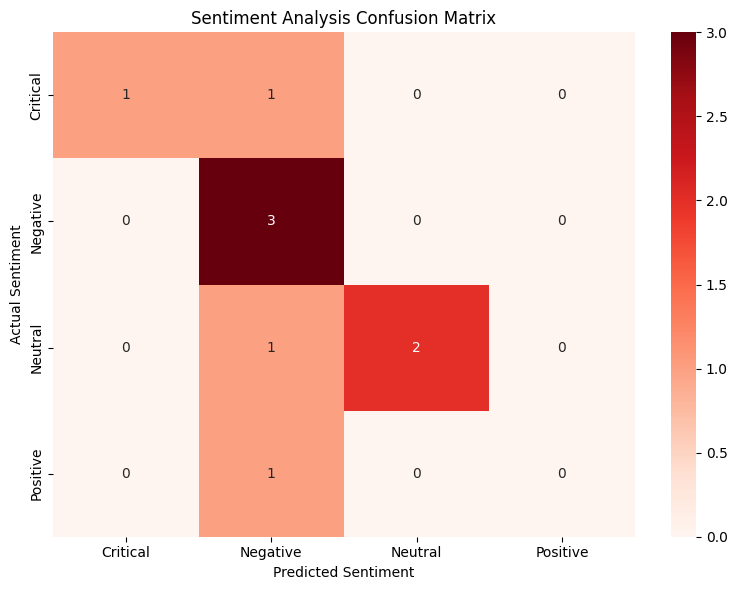

=== SENTIMENT CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

    Critical       1.00      0.50      0.67         2
    Negative       0.50      1.00      0.67         3
     Neutral       1.00      0.67      0.80         3
    Positive       0.00      0.00      0.00         1

    accuracy                           0.67         9
   macro avg       0.62      0.54      0.53         9
weighted avg       0.72      0.67      0.64         9

=== MACRO F1 SCORE ===
Macro F1 Score: 53.33%

This is the KEY metric your sir checks!
High F1 = model finds ALL sentiment classes correctly!


In [7]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions on test data
y_pred = svm.predict(X_test)

# Convert numbers back to labels
y_test_labels = label_encoder.inverse_transform(y_test)
y_pred_labels = label_encoder.inverse_transform(y_pred)

# Confusion Matrix
sentiments = ['Critical', 'Negative', 'Neutral', 'Positive']
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',      # Red theme for urgency!
    xticklabels=sentiments,
    yticklabels=sentiments
)
plt.title('Sentiment Analysis Confusion Matrix')
plt.ylabel('Actual Sentiment')
plt.xlabel('Predicted Sentiment')
plt.tight_layout()
plt.savefig('sentiment_confusion_matrix.png')
plt.show()

# Classification Report
print("=== SENTIMENT CLASSIFICATION REPORT ===\n")
print(classification_report(
    y_test_labels,
    y_pred_labels,
    zero_division=0
))

# Most important metric for this project
print("=== MACRO F1 SCORE ===")
from sklearn.metrics import f1_score
macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"Macro F1 Score: {macro_f1*100:.2f}%")
print("\nThis is the KEY metric your sir checks!")
print("High F1 = model finds ALL sentiment classes correctly!")

In [8]:
# ============================================
# CELL 8A: Import Week1 models into Week2
# ============================================
import pickle

# Save models from Week1 first
# Run this in Week1_EDA.ipynb:
# import pickle
# pickle.dump(vectorizer, open('vectorizer.pkl','wb'))
# pickle.dump(rf_model, open('rf_model.pkl','wb'))

# Load models in Week2
vectorizer = pickle.load(open('vectorizer.pkl','rb'))
rf_model = pickle.load(open('rf_model.pkl','rb'))

print("Week1 models loaded successfully!")

Week1 models loaded successfully!


<h1>Complete Pipeline Test</h1>
<h2>Complete Pipeline Test:</h2>

In [9]:
# ============================================
# DAY 3 - CELL 8: Complete Pipeline Test
# ============================================
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Redefine clean_text here because it was 
# defined in Week1 notebook not this one!
lemmatizer_dept = WordNetLemmatizer()
stop_words_dept = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [lemmatizer_dept.lemmatize(w) 
             for w in words 
             if w not in stop_words_dept]
    return ' '.join(words)

def complete_grievance_analysis(complaint_text):
    """
    Complete pipeline:
    Input  → Raw complaint text
    Output → Department + Sentiment + Priority Score
    """
    
    # ---- DEPARTMENT PREDICTION ----
    dept_cleaned = clean_text(complaint_text)
    dept_vectorized = vectorizer.transform([dept_cleaned])
    department = rf_model.predict(dept_vectorized)[0]
    dept_confidence = rf_model.predict_proba(
        dept_vectorized).max() * 100

    # ---- SENTIMENT PREDICTION ----
    sent_cleaned = clean_sentiment_text(complaint_text)
    sent_vectorized = sentiment_vectorizer.transform(
        [sent_cleaned])
    sentiment_num = svm.predict(sent_vectorized)[0]
    sentiment = label_encoder.inverse_transform(
        [sentiment_num])[0]
    sent_confidence = svm.predict_proba(
        sent_vectorized).max() * 100

    # ---- URGENCY SCORE ----
    base_scores = {
        'Critical': 90,
        'Negative': 60,
        'Neutral':  30,
        'Positive': 10
    }
    urgency_score = round(
        base_scores[sentiment] * (sent_confidence/100), 1)

    # ---- PRIORITY LABEL ----
    if urgency_score >= 70:
        priority = "🚨 URGENT - Act Today!"
    elif urgency_score >= 50:
        priority = "⚠️  HIGH - Act This Week"
    elif urgency_score >= 25:
        priority = "📋 NORMAL - Regular Queue"
    else:
        priority = "✅ LOW - When Possible"

    return {
        'department': department,
        'dept_confidence': dept_confidence,
        'sentiment': sentiment,
        'sent_confidence': sent_confidence,
        'urgency_score': urgency_score,
        'priority': priority
    }

# Test complaints
print("=" * 65)
print("   AI CITIZEN GRIEVANCE ANALYSIS SYSTEM - FULL PIPELINE")
print("=" * 65)

test_complaints = [
    "Electric wire sparking near children school very dangerous urgent",
    "Water not coming in our area since 3 days very frustrated",
    "Please consider installing speed breaker near our school",
    "Thank you for fixing the road so quickly great work",
    "Sewage water overflowing onto street near hospital critical"
]

for i, complaint in enumerate(test_complaints, 1):
    result = complete_grievance_analysis(complaint)
    print(f"\nTicket #{i}")
    print(f"Complaint:   '{complaint[:50]}...'")
    print(f"Department:  {result['department']} "
          f"({result['dept_confidence']:.1f}% confident)")
    print(f"Sentiment:   {result['sentiment']} "
          f"({result['sent_confidence']:.1f}% confident)")
    print(f"Score:       {result['urgency_score']}/100")
    print(f"Priority:    {result['priority']}")
    print("-" * 65)

print("\n✅ Complete Pipeline Working Successfully!")

   AI CITIZEN GRIEVANCE ANALYSIS SYSTEM - FULL PIPELINE

Ticket #1
Complaint:   'Electric wire sparking near children school very d...'
Department:  Electricity (69.0% confident)
Sentiment:   Critical (80.6% confident)
Score:       72.5/100
Priority:    🚨 URGENT - Act Today!
-----------------------------------------------------------------

Ticket #2
Complaint:   'Water not coming in our area since 3 days very fru...'
Department:  Water (47.0% confident)
Sentiment:   Negative (32.2% confident)
Score:       19.3/100
Priority:    ✅ LOW - When Possible
-----------------------------------------------------------------

Ticket #3
Complaint:   'Please consider installing speed breaker near our ...'
Department:  Electricity (57.0% confident)
Sentiment:   Neutral (70.7% confident)
Score:       21.2/100
Priority:    ✅ LOW - When Possible
-----------------------------------------------------------------

Ticket #4
Complaint:   'Thank you for fixing the road so quickly great wor...'
Department:  

<h1>SAVE SENTIMENT MODELS</h1>

In [10]:
import pickle

pickle.dump(sentiment_vectorizer,
            open('sentiment_vectorizer.pkl', 'wb'))
pickle.dump(svm, open('svm_model.pkl', 'wb'))
pickle.dump(label_encoder,
            open('label_encoder.pkl', 'wb'))

print("✅ All sentiment models saved!")
print("sentiment_vectorizer.pkl created")
print("svm_model.pkl created")
print("label_encoder.pkl created")

✅ All sentiment models saved!
sentiment_vectorizer.pkl created
svm_model.pkl created
label_encoder.pkl created
